<a href="https://colab.research.google.com/github/vickramm00/supply--chain-dss/blob/main/ML%20implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [6]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [7]:

import xgboost as xgb

In [8]:
import shap

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
print("=" * 65)
print("  All libraries imported successfully")
print(f"  Pandas     : {pd.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  XGBoost    : {xgb.__version__}")
print(f"  TensorFlow : {tf.__version__}")
print("=" * 65)

  All libraries imported successfully
  Pandas     : 2.2.2
  NumPy      : 2.0.2
  Scikit-learn: 1.6.1
  XGBoost    : 3.2.0
  TensorFlow : 2.19.0


In [11]:
print("\n" + "=" * 65)
print("  STEP 1: DATA LOADING & INITIAL INSPECTION")
print("=" * 65)



  STEP 1: DATA LOADING & INITIAL INSPECTION


In [12]:
FILE_PATH = "bdspref2511.csv"
df = pd.read_csv(FILE_PATH)

print(f"\n[INFO] Dataset loaded successfully")
print(f"       Rows    : {df.shape[0]:,}")
print(f"       Columns : {df.shape[1]}")


[INFO] Dataset loaded successfully
       Rows    : 221,977
       Columns : 10


In [13]:
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Column data types ---")
print(df.dtypes)

print("\n--- Basic statistics (numerical columns) ---")
print(df.describe())


--- First 5 rows ---
  cooalpha codalpha   comcode  statreg eligibility  use  perref  statvalue  \
0       AD       AD  85232100        1          e1  u10  202511       8995   
1       AD       CN  64029998        1          e3  u11  202511      10901   
2       AD       ES  85235200        1          e1  u10  202511    1618239   
3       AD       ES  85423190        1          e1  u10  202511      52750   
4       AD       FR  87120070        1          e3  u11  202511       3417   

   netmass  suppunit  
0        1         6  
1     1543      2204  
2     9550   1782509  
3       30         0  
4      109         1  

--- Column data types ---
cooalpha       object
codalpha       object
comcode         int64
statreg         int64
eligibility    object
use            object
perref          int64
statvalue       int64
netmass         int64
suppunit        int64
dtype: object

--- Basic statistics (numerical columns) ---
            comcode        statreg    perref     statvalue      

In [14]:
print("\n--- Missing values per column ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])



--- Missing values per column ---
          Missing Count  Missing %
cooalpha             12     0.0054
codalpha             12     0.0054


In [15]:
print("\n--- Unique values per column ---")
for col in df.columns:
    print(f"  {col:<15}: {df[col].nunique():>5} unique values")


--- Unique values per column ---
  cooalpha       :   215 unique values
  codalpha       :   199 unique values
  comcode        :  8237 unique values
  statreg        :     3 unique values
  eligibility    :     4 unique values
  use            :     7 unique values
  perref         :     1 unique values
  statvalue      : 86737 unique values
  netmass        : 36733 unique values
  suppunit       : 11811 unique values


In [16]:
print("\n" + "=" * 65)
print("  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 65)


  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


In [17]:
print("\n--- Target variable: eligibility ---")
elig_counts = df['eligibility'].value_counts()
elig_pct    = df['eligibility'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': elig_counts, 'Percentage %': elig_pct.round(2)}))


--- Target variable: eligibility ---
              Count  Percentage %
eligibility                      
e1           131572         59.27
e3            79656         35.88
e2            10594          4.77
e5              155          0.07


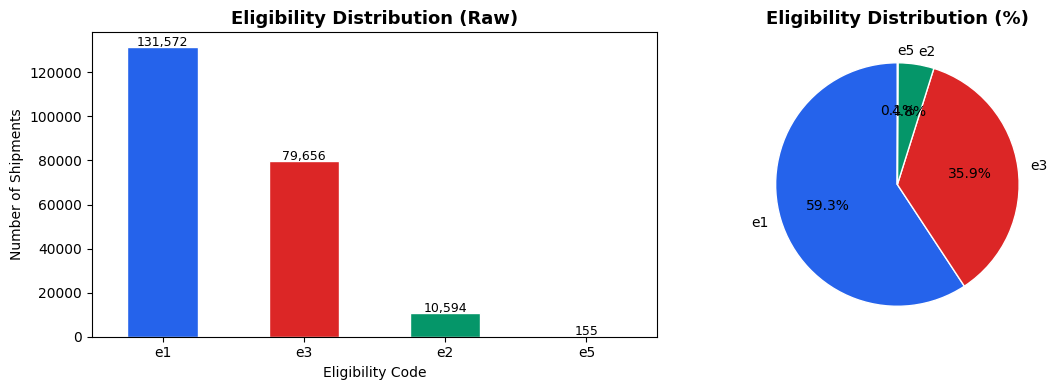

[SAVED] eda_01_eligibility_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

elig_counts.plot(kind='bar', ax=axes[0], color=['#2563EB','#DC2626','#059669','#D97706'],
                 edgecolor='white')
axes[0].set_title('Eligibility Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Eligibility Code')
axes[0].set_ylabel('Number of Shipments')
axes[0].tick_params(axis='x', rotation=0)
for bar, count in zip(axes[0].patches, elig_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{count:,}', ha='center', fontsize=9)

elig_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
              colors=['#2563EB','#DC2626','#059669','#D97706'],
              startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Eligibility Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_01_eligibility_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_01_eligibility_distribution.png")

In [19]:
print("\n--- Top 10 countries of origin (cooalpha) ---")
top_origins = df['cooalpha'].value_counts().head(10)
print(top_origins)


--- Top 10 countries of origin (cooalpha) ---
cooalpha
CN    25386
DE    15394
US    15138
IT    13571
GB    10640
FR     9952
ES     7134
PL     6979
IN     6809
JP     6317
Name: count, dtype: int64


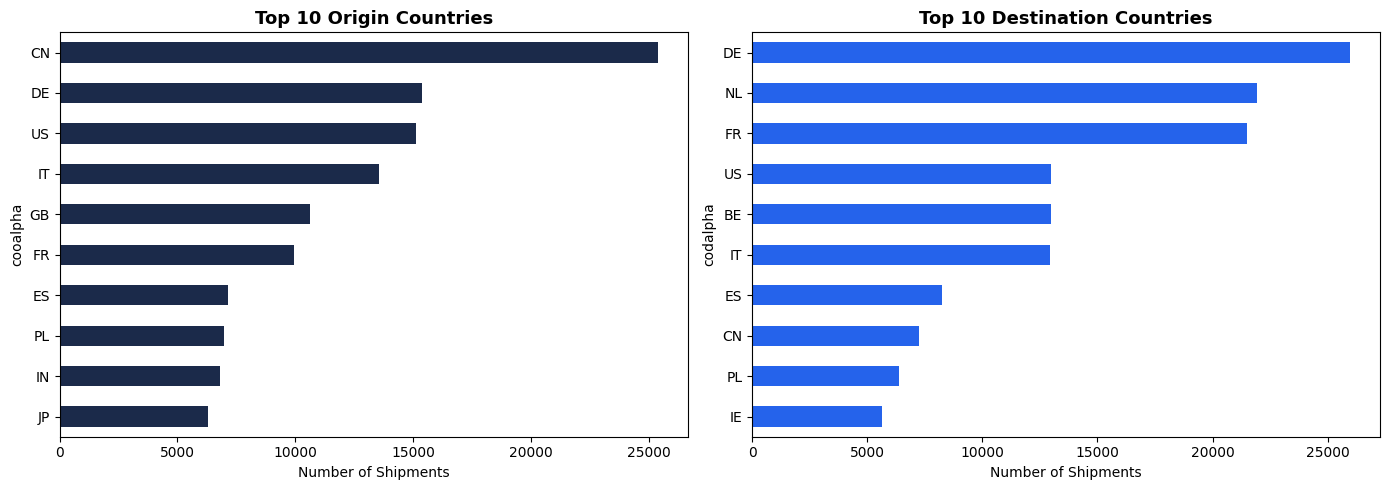

[SAVED] eda_02_top_countries.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_origins.plot(kind='barh', ax=axes[0], color='#1B2A4A')
axes[0].set_title('Top 10 Origin Countries', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Shipments')
axes[0].invert_yaxis()

top_dest.plot(kind='barh', ax=axes[1], color='#2563EB')
axes[1].set_title('Top 10 Destination Countries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Shipments')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_02_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_02_top_countries.png")


--- Eligibility breakdown for Top 10 origin countries ---
eligibility     e1    e2    e3
cooalpha                      
CN           25386     0     0
DE            7386     0  8008
ES            2782     0  4352
FR            4381     0  5571
GB           10640     0     0
IN            3787  3022     0
IT            4962     0  8609
JP            3185     0  3132
PL            2860     0  4119
US           15128     0    10


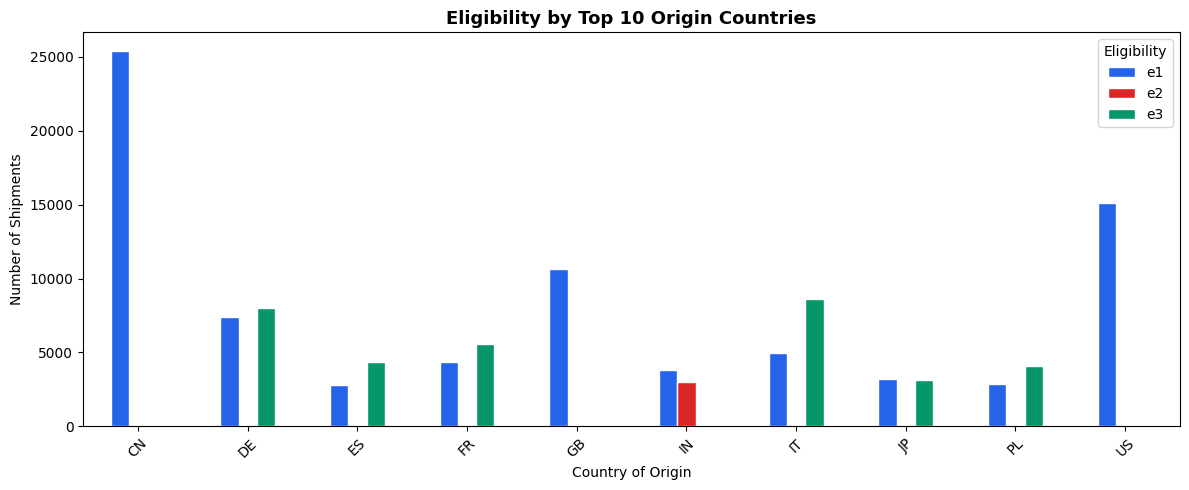

[SAVED] eda_03_eligibility_by_origin.png


In [22]:
print("\n--- Eligibility breakdown for Top 10 origin countries ---")
top10_origin_list = top_origins.index.tolist()
elig_by_origin = (
    df[df['cooalpha'].isin(top10_origin_list)]
    .groupby(['cooalpha', 'eligibility'])
    .size()
    .unstack(fill_value=0)
)
print(elig_by_origin)

elig_by_origin.plot(kind='bar', figsize=(12, 5),
                    color=['#2563EB','#DC2626','#059669','#D97706'],
                    edgecolor='white')
plt.title('Eligibility by Top 10 Origin Countries', fontsize=13, fontweight='bold')
plt.xlabel('Country of Origin')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=45)
plt.legend(title='Eligibility')
plt.tight_layout()
plt.savefig('eda_03_eligibility_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_03_eligibility_by_origin.png")

In [23]:
print("\n--- Use code distribution ---")
print(df['use'].value_counts())


--- Use code distribution ---
use
u10    102623
u11     71663
u30     43141
u20      3476
u21       891
u31       180
uzz         3
Name: count, dtype: int64



--- statvalue distribution ---
  Min    : £              1
  Mean   : £        269,026
  Median : £          9,882
  Max    : £  4,053,265,711
  Std Dev: £     11,997,582


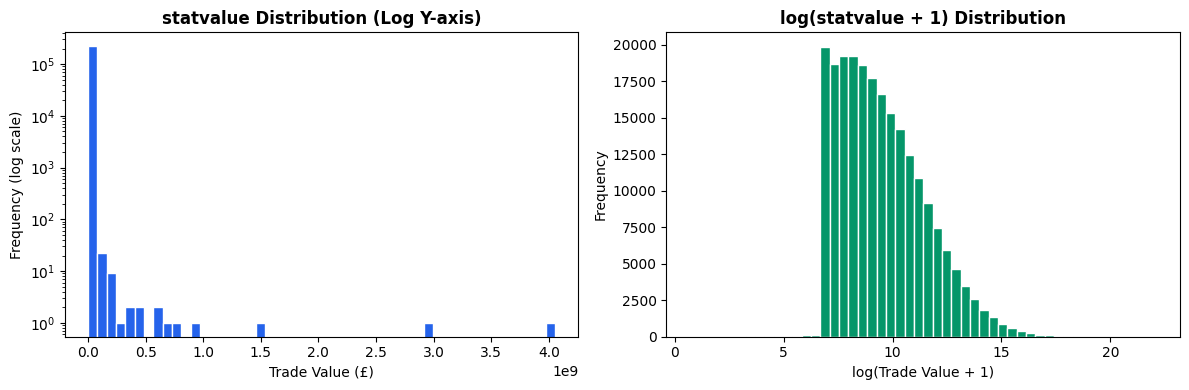

[SAVED] eda_04_statvalue_distribution.png


In [24]:
print("\n--- statvalue distribution ---")
print(f"  Min    : £{df['statvalue'].min():>15,.0f}")
print(f"  Mean   : £{df['statvalue'].mean():>15,.0f}")
print(f"  Median : £{df['statvalue'].median():>15,.0f}")
print(f"  Max    : £{df['statvalue'].max():>15,.0f}")
print(f"  Std Dev: £{df['statvalue'].std():>15,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['statvalue'], bins=50, color='#2563EB', edgecolor='white', log=True)
axes[0].set_title('statvalue Distribution (Log Y-axis)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trade Value (£)')
axes[0].set_ylabel('Frequency (log scale)')

log_vals = np.log1p(df['statvalue'])
axes[1].hist(log_vals, bins=50, color='#059669', edgecolor='white')
axes[1].set_title('log(statvalue + 1) Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Trade Value + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_04_statvalue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_04_statvalue_distribution.png")

In [25]:
print(f"\n--- Zero-value entries ---")
print(f"  netmass  = 0 : {(df['netmass']  == 0).sum():,} rows ({(df['netmass']==0).mean()*100:.2f}%)")
print(f"  suppunit = 0 : {(df['suppunit'] == 0).sum():,} rows ({(df['suppunit']==0).mean()*100:.2f}%)")
print(f"  statvalue= 0 : {(df['statvalue']== 0).sum():,} rows")

print("\n[INFO] EDA complete — 4 charts saved")


--- Zero-value entries ---
  netmass  = 0 : 4,794 rows (2.16%)
  suppunit = 0 : 160,798 rows (72.44%)
  statvalue= 0 : 0 rows

[INFO] EDA complete — 4 charts saved


In [26]:
print("\n" + "=" * 65)
print("  STEP 3: DATA CLEANING")
print("=" * 65)

df_clean = df.copy()
original_size = len(df_clean)


  STEP 3: DATA CLEANING


In [27]:
missing_mask = df_clean['cooalpha'].isna() | df_clean['codalpha'].isna()
df_clean = df_clean[~missing_mask].reset_index(drop=True)
dropped = original_size - len(df_clean)
print(f"\n[CLEAN] Dropped {dropped} rows with missing country codes")
print(f"        Remaining rows: {len(df_clean):,}")


[CLEAN] Dropped 20 rows with missing country codes
        Remaining rows: 221,957


In [28]:
print(f"\n[CLEAN] Unique perref values: {df_clean['perref'].nunique()}")
df_clean.drop(columns=['perref'], inplace=True)
print(f"        Dropped column 'perref' (constant value 202511 — adds no information)")


[CLEAN] Unique perref values: 1
        Dropped column 'perref' (constant value 202511 — adds no information)


In [29]:
print(f"\n[CLEAN] Zero netmass entries: {(df_clean['netmass'] == 0).sum():,}")
print(f"        These are valid (digital goods / services) — kept, not dropped")


[CLEAN] Zero netmass entries: 4,791
        These are valid (digital goods / services) — kept, not dropped


In [30]:
uzz_count = (df_clean['use'] == 'uzz').sum()
df_clean = df_clean[df_clean['use'] != 'uzz'].reset_index(drop=True)
print(f"\n[CLEAN] Removed {uzz_count} rows with use='uzz' (unclassified, negligible)")


[CLEAN] Removed 3 rows with use='uzz' (unclassified, negligible)


In [31]:
print(f"\n[CLEAN] Dataset size after cleaning: {len(df_clean):,} rows x {df_clean.shape[1]} columns")
print(f"        Rows removed: {original_size - len(df_clean):,} ({(original_size - len(df_clean))/original_size*100:.3f}%)")
print(f"        Remaining missing values: {df_clean.isnull().sum().sum()}")


[CLEAN] Dataset size after cleaning: 221,954 rows x 9 columns
        Rows removed: 23 (0.010%)
        Remaining missing values: 0


In [32]:
print("\n" + "=" * 65)
print("  STEP 4: FEATURE ENGINEERING")
print("=" * 65)


  STEP 4: FEATURE ENGINEERING


In [49]:
df_clean['hs_chapter'] = df_clean['comcode'].astype(str).str[:2].astype(int)
print(f"\n[clean] Created 'hs_chapter' (first 2 digits of comcode)")
print(f"       Unique comcodes  : {df_clean['comcode'].nunique():,}")
print(f"       Unique hs_chapters: {df_clean['hs_chapter'].nunique()}")
print(f"       Top 5 chapters:\n{df_clean['hs_chapter'].value_counts().head()}")


[clean] Created 'hs_chapter' (first 2 digits of comcode)
       Unique comcodes  : 8,237
       Unique hs_chapters: 87
       Top 5 chapters:
hs_chapter
84    33094
85    29195
90    14713
62    10516
39     9681
Name: count, dtype: int64


In [48]:
df_clean['trade_route'] = df_clean['cooalpha'] + '_' + df_clean['codalpha']
print(f"\n[clean] Created 'trade_route' (cooalpha + '_' + codalpha)")
print(f"       Unique trade routes: {df_clean['trade_route'].nunique():,}")
print(f"       Top 5 routes:\n{df_clean['trade_route'].value_counts().head()}")


[clean] Created 'trade_route' (cooalpha + '_' + codalpha)
       Unique trade routes: 4,088
       Top 5 routes:
trade_route
DE_DE    5757
IT_IT    5445
CN_CN    5299
FR_FR    4738
US_US    4489
Name: count, dtype: int64


In [41]:
df_clean['value_per_kg'] = np.where(
    df_clean['netmass'] > 0,
    df_clean['statvalue'] / df_clean['netmass'],
    0
)
print(f"\n[clean] Created 'value_per_kg' (statvalue / netmass)")
print(f"       Rows where netmass=0 → value_per_kg set to 0: {(df_clean['netmass']==0).sum():,}")
print(f"       value_per_kg statistics:")
print(df_clean['value_per_kg'].describe().round(2))


[clean] Created 'value_per_kg' (statvalue / netmass)
       Rows where netmass=0 → value_per_kg set to 0: 4,791
       value_per_kg statistics:
count      221954.00
mean          713.46
std         29081.55
min             0.00
25%             7.09
50%            30.77
75%           159.77
max      12466950.00
Name: value_per_kg, dtype: float64


In [47]:
df_clean['log_statvalue'] = np.log1p(df_clean['statvalue'])
df_clean['log_netmass']   = np.log1p(df_clean['netmass'])
df_clean['log_suppunit']  = np.log1p(df_clean['suppunit'])
df_clean['log_value_per_kg'] = np.log1p(df_clean['value_per_kg'])

print(f"\n[clean] Log transformations applied (log1p):")
print(f"       log_statvalue  : mean={df_clean['log_statvalue'].mean():.3f}, std={df_clean['log_statvalue'].std():.3f}")
print(f"       log_netmass    : mean={df_clean['log_netmass'].mean():.3f}, std={df_clean['log_netmass'].std():.3f}")
print(f"       log_suppunit   : mean={df_clean['log_suppunit'].mean():.3f}, std={df_clean['log_suppunit'].std():.3f}")
print(f"       log_value_per_kg: mean={df_clean['log_value_per_kg'].mean():.3f}, std={df_clean['log_value_per_kg'].std():.3f}")


[clean] Log transformations applied (log1p):
       log_statvalue  : mean=9.508, std=1.976
       log_netmass    : mean=5.823, std=3.178
       log_suppunit   : mean=1.359, std=2.781
       log_value_per_kg: mean=3.690, std=2.115


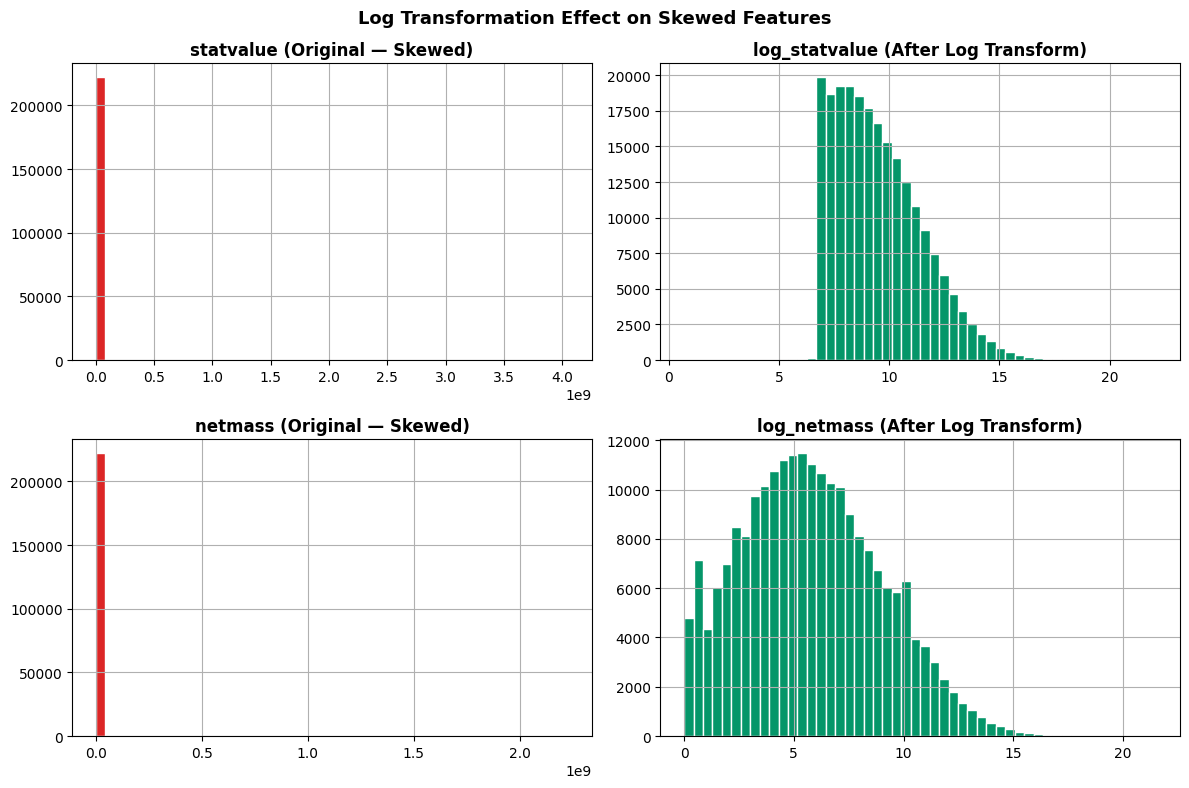

[SAVED] feat_01_log_transforms.png


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_before = ['statvalue','netmass']
cols_after  = ['log_statvalue','log_netmass']

for i, (before, after) in enumerate(zip(cols_before, cols_after)):
    df_clean[before].hist(bins=50, ax=axes[i][0], color='#DC2626', edgecolor='white')
    axes[i][0].set_title(f'{before} (Original — Skewed)', fontweight='bold')

    df_clean[after].hist(bins=50, ax=axes[i][1], color='#059669', edgecolor='white')
    axes[i][1].set_title(f'{after} (After Log Transform)', fontweight='bold')

plt.suptitle('Log Transformation Effect on Skewed Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feat_01_log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] feat_01_log_transforms.png")

In [46]:
print(f"\n[clean] All features after engineering:")
for col in df_clean.columns:
    print(f"       {col:<25} | dtype: {str(df_clean[col].dtype):<10} | unique: {df_clean[col].nunique()}")


[clean] All features after engineering:
       cooalpha                  | dtype: object     | unique: 215
       codalpha                  | dtype: object     | unique: 199
       comcode                   | dtype: int64      | unique: 8237
       statreg                   | dtype: int64      | unique: 3
       eligibility               | dtype: object     | unique: 4
       use                       | dtype: object     | unique: 6
       statvalue                 | dtype: int64      | unique: 86731
       netmass                   | dtype: int64      | unique: 36728
       suppunit                  | dtype: int64      | unique: 11810
       hs_chapter                | dtype: int64      | unique: 87
       trade_route               | dtype: object     | unique: 4088
       value_per_kg              | dtype: float64    | unique: 190373
       log_statvalue             | dtype: float64    | unique: 86731
       log_netmass               | dtype: float64    | unique: 36728
       log_su

In [50]:
print("\n" + "=" * 65)
print("  STEP 5: TARGET VARIABLE ENCODING")
print("=" * 65)


  STEP 5: TARGET VARIABLE ENCODING


In [51]:
eligibility_map = {'e1': 1, 'e2': 1, 'e3': 0, 'e5': 0}
df_clean['target'] = df_clean['eligibility'].map(eligibility_map)

print(f"\n[TARGET] Encoding: e1→1, e2→1 (Eligible) | e3→0, e5→0 (Not Eligible)")
target_dist = df_clean['target'].value_counts()
target_pct  = df_clean['target'].value_counts(normalize=True) * 100
print(pd.DataFrame({
    'Label'     : {1: 'Eligible (1)', 0: 'Not Eligible (0)'},
    'Count'     : target_dist,
    'Percentage': target_pct.round(2)
}))

class_ratio = target_dist[1] / target_dist[0]
print(f"\n[INFO] Class ratio (eligible:not eligible) = {class_ratio:.2f}:1")
print(f"       Imbalance is mild — stratified split is sufficient (no SMOTE needed)")


[TARGET] Encoding: e1→1, e2→1 (Eligible) | e3→0, e5→0 (Not Eligible)
              Label   Count  Percentage
1      Eligible (1)  142147       64.04
0  Not Eligible (0)   79807       35.96

[INFO] Class ratio (eligible:not eligible) = 1.78:1
       Imbalance is mild — stratified split is sufficient (no SMOTE needed)


In [53]:
print("\n" + "=" * 65)
print("  STEP 6: CATEGORICAL FEATURE ENCODING")
print("=" * 65)

df_enc = df_clean.copy()


  STEP 6: CATEGORICAL FEATURE ENCODING


In [54]:
print("\n[ENCODE] One-Hot Encoding: statreg, use")
df_enc = pd.get_dummies(df_enc,
                         columns=['statreg', 'use'],
                         prefix=['statreg', 'use'],
                         drop_first=False)

new_ohe_cols = [c for c in df_enc.columns if c.startswith('statreg_') or c.startswith('use_')]
print(f"         Columns created: {new_ohe_cols}")


[ENCODE] One-Hot Encoding: statreg, use
         Columns created: ['statreg_1', 'statreg_2', 'statreg_3', 'use_u10', 'use_u11', 'use_u20', 'use_u21', 'use_u30', 'use_u31']


In [55]:
print("\n[ENCODE] Label Encoding: cooalpha, codalpha, trade_route")
le_coo   = LabelEncoder()
le_cod   = LabelEncoder()
le_route = LabelEncoder()

df_enc['cooalpha_enc']    = le_coo.fit_transform(df_enc['cooalpha'])
df_enc['codalpha_enc']    = le_cod.fit_transform(df_enc['codalpha'])
df_enc['trade_route_enc'] = le_route.fit_transform(df_enc['trade_route'])

print(f"         cooalpha    → {df_enc['cooalpha_enc'].nunique()} encoded values (0–{df_enc['cooalpha_enc'].max()})")
print(f"         codalpha    → {df_enc['codalpha_enc'].nunique()} encoded values (0–{df_enc['codalpha_enc'].max()})")
print(f"         trade_route → {df_enc['trade_route_enc'].nunique()} encoded values")


[ENCODE] Label Encoding: cooalpha, codalpha, trade_route
         cooalpha    → 215 encoded values (0–214)
         codalpha    → 199 encoded values (0–198)
         trade_route → 4088 encoded values


In [56]:

cols_to_drop = [
    'cooalpha', 'codalpha', 'comcode',
    'eligibility', 'trade_route',
    'statvalue', 'netmass', 'suppunit', 'value_per_kg'
    # ^ dropping originals — keeping log-transformed versions
]
df_enc.drop(columns=cols_to_drop, inplace=True)
print(f"\n[ENCODE] Dropped original/intermediate columns: {cols_to_drop}")


[ENCODE] Dropped original/intermediate columns: ['cooalpha', 'codalpha', 'comcode', 'eligibility', 'trade_route', 'statvalue', 'netmass', 'suppunit', 'value_per_kg']


In [57]:
feature_cols = [c for c in df_enc.columns if c != 'target']
print(f"\n[ENCODE] Final feature matrix: {len(df_enc):,} rows × {len(feature_cols)} features")
print(f"         Features:")
for col in feature_cols:
    print(f"           {col}")


[ENCODE] Final feature matrix: 221,954 rows × 17 features
         Features:
           hs_chapter
           log_statvalue
           log_netmass
           log_suppunit
           log_value_per_kg
           statreg_1
           statreg_2
           statreg_3
           use_u10
           use_u11
           use_u20
           use_u21
           use_u30
           use_u31
           cooalpha_enc
           codalpha_enc
           trade_route_enc


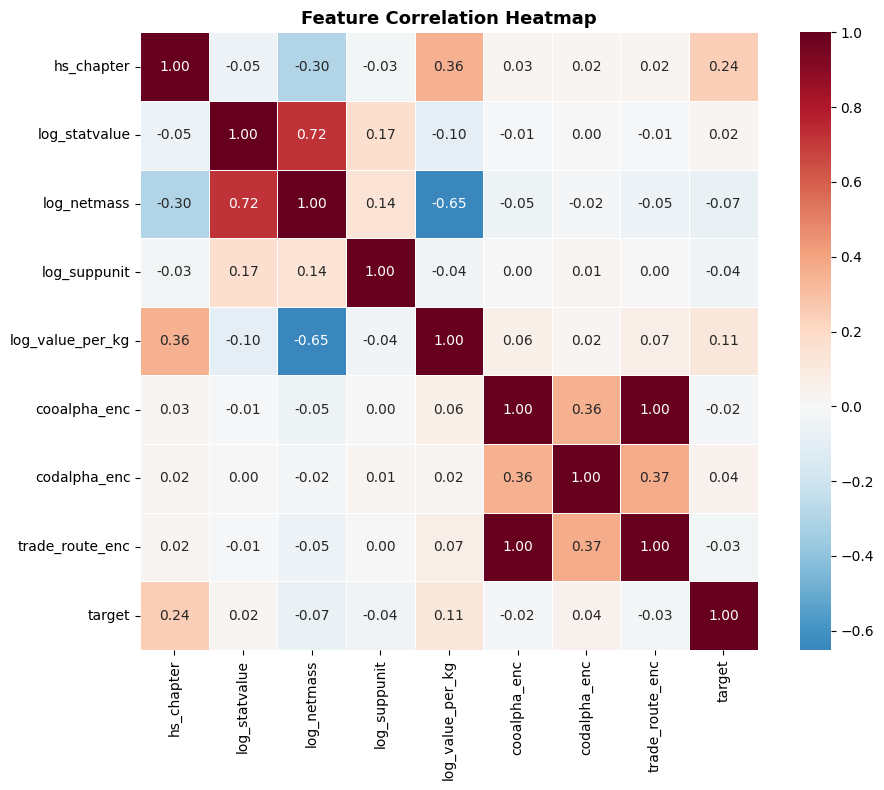

[SAVED] clean_02_correlation_heatmap.png


In [59]:
num_features = ['hs_chapter','log_statvalue','log_netmass',
                'log_suppunit','log_value_per_kg',
                'cooalpha_enc','codalpha_enc','trade_route_enc','target']
corr = df_enc[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] clean_02_correlation_heatmap.png")

In [60]:
print("\n" + "=" * 65)
print("  STEP 7: TRAIN / TEST SPLIT")
print("=" * 65)

# Define X (features) and y (target)
X = df_enc[feature_cols].values
y = df_enc['target'].values

print(f"\n[SPLIT] Feature matrix X shape : {X.shape}")
print(f"[SPLIT] Target vector  y shape : {y.shape}")
print(f"[SPLIT] Class distribution in y:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Eligible' if cls == 1 else 'Not Eligible'
    print(f"         {cls} ({label:<15}): {cnt:,} ({cnt/len(y)*100:.2f}%)")


  STEP 7: TRAIN / TEST SPLIT

[SPLIT] Feature matrix X shape : (221954, 17)
[SPLIT] Target vector  y shape : (221954,)
[SPLIT] Class distribution in y:
         0 (Not Eligible   ): 79,807 (35.96%)
         1 (Eligible       ): 142,147 (64.04%)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # critical: maintains class balance
)

print(f"\n[SPLIT] Training set  : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"[SPLIT] Test set      : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
train_pos = y_train.sum() / len(y_train) * 100
test_pos  = y_test.sum()  / len(y_test)  * 100
print(f"\n[VERIFY] Eligible % in training set : {train_pos:.2f}%")
print(f"[VERIFY] Eligible % in test set     : {test_pos:.2f}%")
print(f"[VERIFY] Stratification preserved ✓" if abs(train_pos - test_pos) < 0.5 else "[WARN] Stratification mismatch!")


[SPLIT] Training set  : 177,563 rows (80.0%)
[SPLIT] Test set      : 44,391 rows (20.0%)

[VERIFY] Eligible % in training set : 64.04%
[VERIFY] Eligible % in test set     : 64.04%
[VERIFY] Stratification preserved ✓


In [62]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data ONLY
X_test_scaled  = scaler.transform(X_test)       # apply same scaling to test

print(f"\n[SCALE] StandardScaler applied")
print(f"        Fitted on training set only (prevents data leakage)")
print(f"        X_train_scaled: mean≈0, std≈1 per feature")
print(f"        X_test_scaled : same transformation applied")

print(f"\n[INFO] Feature list used for all models:")
for i, col in enumerate(feature_cols):
    print(f"       {i+1:>2}. {col}")


[SCALE] StandardScaler applied
        Fitted on training set only (prevents data leakage)
        X_train_scaled: mean≈0, std≈1 per feature
        X_test_scaled : same transformation applied

[INFO] Feature list used for all models:
        1. hs_chapter
        2. log_statvalue
        3. log_netmass
        4. log_suppunit
        5. log_value_per_kg
        6. statreg_1
        7. statreg_2
        8. statreg_3
        9. use_u10
       10. use_u11
       11. use_u20
       12. use_u21
       13. use_u30
       14. use_u31
       15. cooalpha_enc
       16. codalpha_enc
       17. trade_route_enc


In [64]:
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    """
    Prints and plots a full evaluation report for a classifier.

    Parameters
    ----------
    model_name : str
        Name of the model for display purposes.
    y_true     : array-like
        True binary labels (0 or 1).
    y_pred     : array-like
        Predicted binary labels (0 or 1).
    y_prob     : array-like or None
        Predicted probabilities for the positive class.
        If provided, ROC-AUC is computed.
    """
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*55}")
    print(f"  RESULTS: {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy     : {acc*100:.2f}%")
    print(f"  F1-Score     : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC      : {auc:.4f}")
    print(f"  True Positives  (TP): {tp:,}  — correctly predicted eligible")
    print(f"  True Negatives  (TN): {tn:,}  — correctly predicted not eligible")
    print(f"  False Positives (FP): {fp:,}  — predicted eligible, actually not")
    print(f"  False Negatives (FN): {fn:,}  — predicted not eligible, actually eligible")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Not Eligible (0)', 'Eligible (1)']))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Eligible', 'Eligible'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ","_").replace("/","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {fname}")

    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc}


# Collect all results for final comparison
results = []

In [65]:
print("\n" + "=" * 65)
print("  MODEL 1: LOGISTIC REGRESSION — BASELINE")
print("=" * 65)


  MODEL 1: LOGISTIC REGRESSION — BASELINE



  MODEL 1: LOGISTIC REGRESSION — BASELINE

[LR] Training Logistic Regression...
[LR] Training complete

  RESULTS: Logistic Regression
  Accuracy     : 86.87%
  F1-Score     : 0.8686
  ROC-AUC      : 0.9587
  True Positives  (TP): 25,557  — correctly predicted eligible
  True Negatives  (TN): 13,004  — correctly predicted not eligible
  False Positives (FP): 2,957  — predicted eligible, actually not
  False Negatives (FN): 2,873  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.82      0.81      0.82     15961
    Eligible (1)       0.90      0.90      0.90     28430

        accuracy                           0.87     44391
       macro avg       0.86      0.86      0.86     44391
    weighted avg       0.87      0.87      0.87     44391



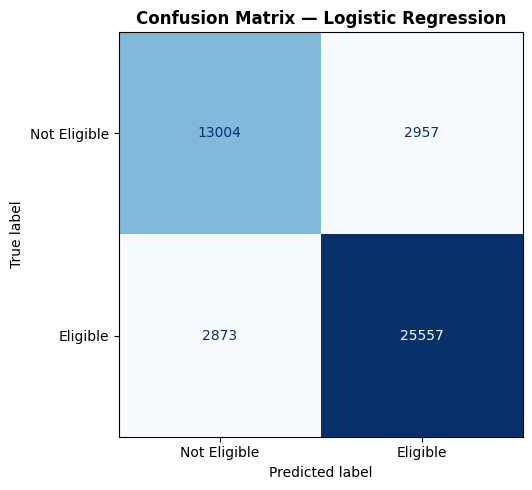

[SAVED] cm_logistic_regression.png

[LR] Top 10 most influential features (by coefficient magnitude):
        Feature  Coefficient
        use_u30    -5.970949
trade_route_enc    -4.963050
   cooalpha_enc     4.713929
        use_u10     3.686434
        use_u21     1.336090
        use_u20     0.790361
        use_u11     0.753924
        use_u31    -0.410496
   codalpha_enc     0.274658
    log_netmass     0.260968


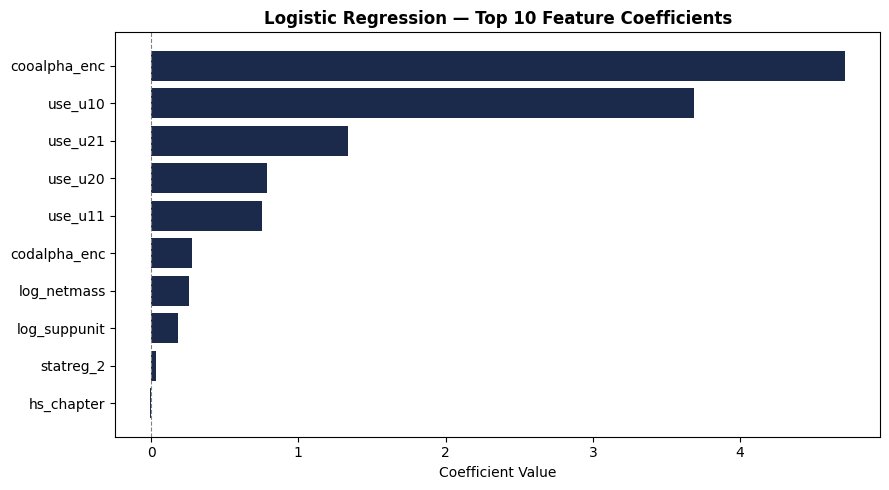

[SAVED] lr_feature_coefficients.png


In [66]:

print("\n" + "=" * 65)
print("  MODEL 1: LOGISTIC REGRESSION — BASELINE")
print("=" * 65)

# Why Logistic Regression?
# - Simplest classification algorithm → establishes performance floor
# - Any complex model must clearly beat this to justify added complexity
# - Fully interpretable coefficients show which features drive predictions
# - Uses scaled features (important for LR)

print("\n[LR] Training Logistic Regression...")
lr_model = LogisticRegression(
    C=1.0,              # regularisation strength (1/lambda) — default
    penalty='l2',       # L2 (Ridge) regularisation — penalises large coefficients
    solver='lbfgs',     # efficient solver for multiclass + L2
    max_iter=1000,      # ensure convergence
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability for class 1

print("[LR] Training complete")
res_lr = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
results.append(res_lr)

# Feature importance (coefficients)
print("\n[LR] Top 10 most influential features (by coefficient magnitude):")
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_[0]
}).reindex(lr_model.coef_[0].argsort()[::-1])
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.nlargest(10, 'Abs_Coefficient')
print(coef_df[['Feature','Coefficient']].to_string(index=False))

plt.figure(figsize=(9, 5))
coef_df_plot = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_[0]
}).nlargest(10, 'Coefficient')
plt.barh(coef_df_plot['Feature'], coef_df_plot['Coefficient'], color='#1B2A4A')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression — Top 10 Feature Coefficients', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('lr_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] lr_feature_coefficients.png")

In [67]:
print("\n" + "=" * 65)
print("  MODEL 2: RANDOM FOREST — PRIMARY MODEL")
print("=" * 65)


  MODEL 2: RANDOM FOREST — PRIMARY MODEL



[RF] Training Random Forest (this may take 1-2 minutes)...
[RF] Training complete

  RESULTS: Random Forest
  Accuracy     : 99.19%
  F1-Score     : 0.9919
  ROC-AUC      : 0.9992
  True Positives  (TP): 28,163  — correctly predicted eligible
  True Negatives  (TN): 15,867  — correctly predicted not eligible
  False Positives (FP): 94  — predicted eligible, actually not
  False Negatives (FN): 267  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.98      0.99      0.99     15961
    Eligible (1)       1.00      0.99      0.99     28430

        accuracy                           0.99     44391
       macro avg       0.99      0.99      0.99     44391
    weighted avg       0.99      0.99      0.99     44391



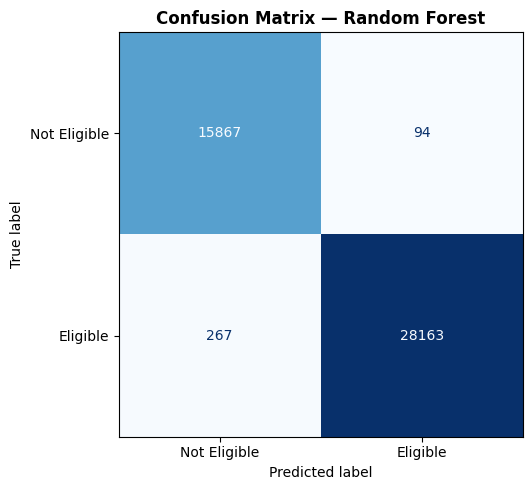

[SAVED] cm_random_forest.png


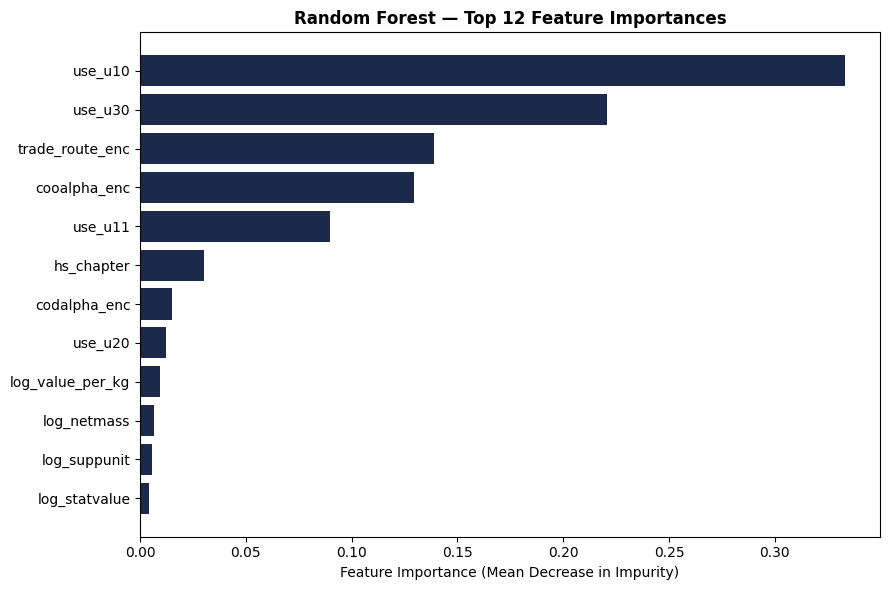

[SAVED] rf_feature_importance.png

[RF] Top 12 most important features:
         Feature  Importance
         use_u10    0.333117
         use_u30    0.220696
 trade_route_enc    0.138743
    cooalpha_enc    0.129555
         use_u11    0.089823
      hs_chapter    0.030116
    codalpha_enc    0.015275
         use_u20    0.012246
log_value_per_kg    0.009302
     log_netmass    0.006364
    log_suppunit    0.005849
   log_statvalue    0.004058


In [68]:

print("\n[RF] Training Random Forest (this may take 1-2 minutes)...")
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees — more = better but slower
    max_depth=20,            # maximum depth of each tree
    min_samples_split=10,    # minimum samples needed to split a node
    min_samples_leaf=5,      # minimum samples in each leaf node
    max_features='sqrt',     # number of features to consider at each split
    class_weight='balanced', # handles mild class imbalance automatically
    random_state=42,
    n_jobs=-1                # use all CPU cores for parallel training
)

rf_model.fit(X_train, y_train)   # No scaling needed for RF

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("[RF] Training complete")
res_rf = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
results.append(res_rf)

# Feature importance plot
rf_importances = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(rf_importances['Feature'], rf_importances['Importance'], color='#1B2A4A')
plt.title('Random Forest — Top 12 Feature Importances', fontweight='bold')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] rf_feature_importance.png")
print("\n[RF] Top 12 most important features:")
print(rf_importances.to_string(index=False))

In [69]:
print("\n" + "=" * 65)
print("  MODEL 3: XGBOOST — PRIMARY MODEL + SHAP EXPLAINABILITY")
print("=" * 65)


  MODEL 3: XGBOOST — PRIMARY MODEL + SHAP EXPLAINABILITY



[XGB] Training XGBoost...
[XGB] Training complete

  RESULTS: XGBoost
  Accuracy     : 99.67%
  F1-Score     : 0.9967
  ROC-AUC      : 0.9997
  True Positives  (TP): 28,353  — correctly predicted eligible
  True Negatives  (TN): 15,892  — correctly predicted not eligible
  False Positives (FP): 69  — predicted eligible, actually not
  False Negatives (FN): 77  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       1.00      1.00      1.00     15961
    Eligible (1)       1.00      1.00      1.00     28430

        accuracy                           1.00     44391
       macro avg       1.00      1.00      1.00     44391
    weighted avg       1.00      1.00      1.00     44391



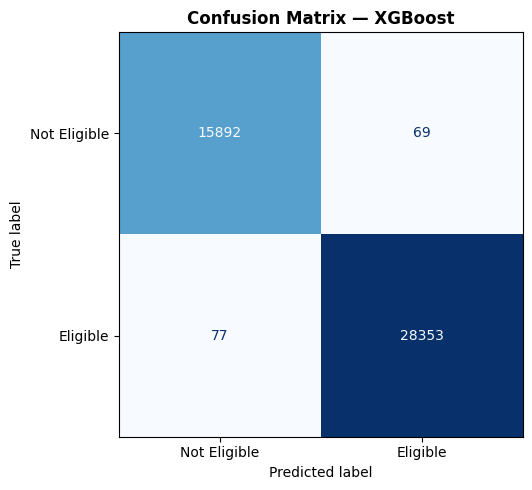

[SAVED] cm_xgboost.png


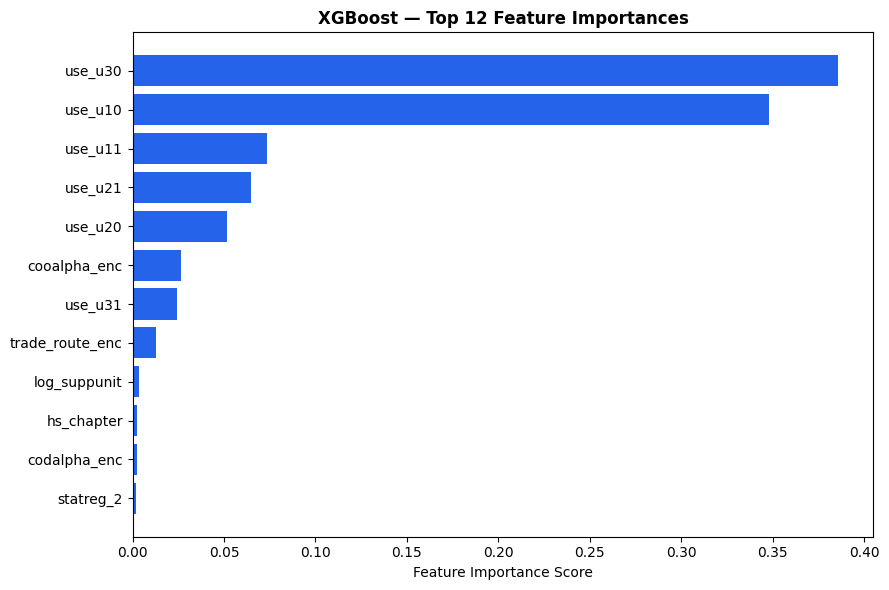

[SAVED] xgb_feature_importance.png

[SHAP] Computing SHAP values (this may take ~30 seconds)...
       SHAP = SHapley Additive exPlanations
       Tells us WHY the model made each prediction


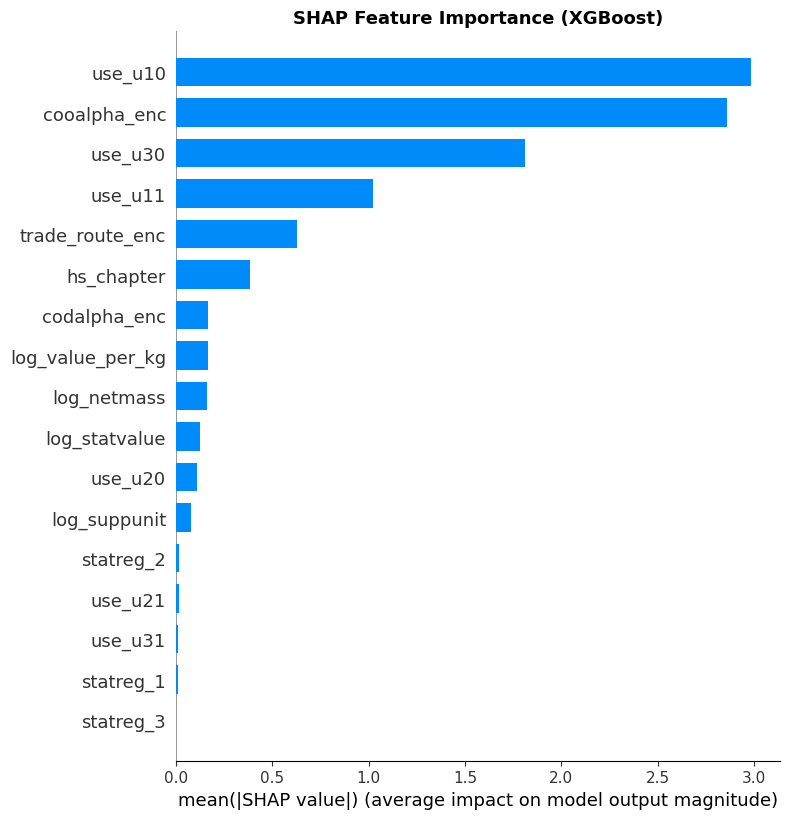

[SAVED] shap_summary_bar.png


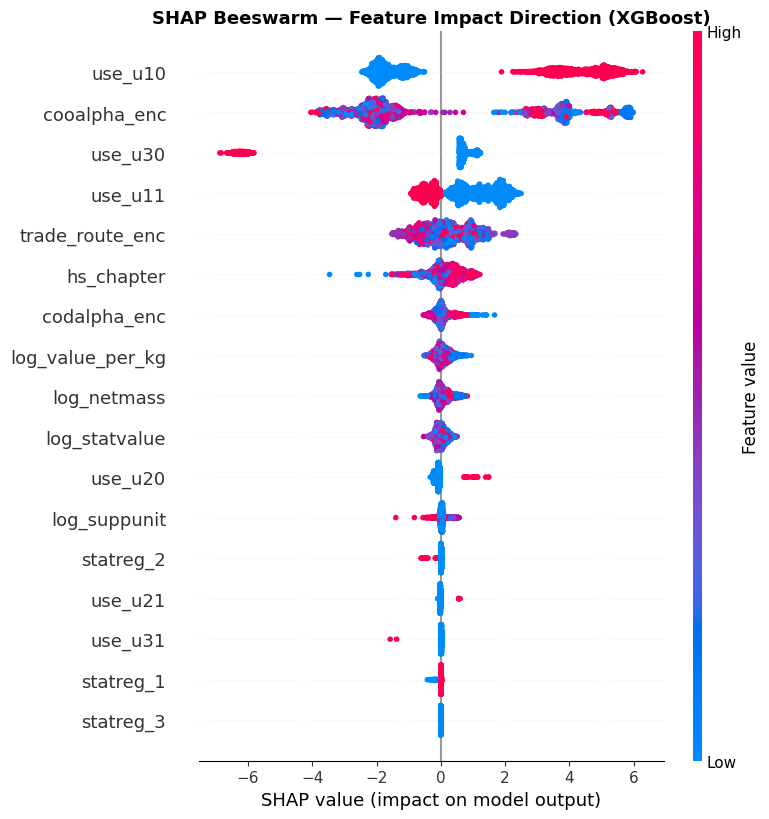

[SAVED] shap_summary_beeswarm.png

[SHAP] Explaining a single prediction (waterfall plot):
       Shipment sample index: 10665
       True label : Not Eligible
       Predicted  : Not Eligible
       Probability: 0.0008


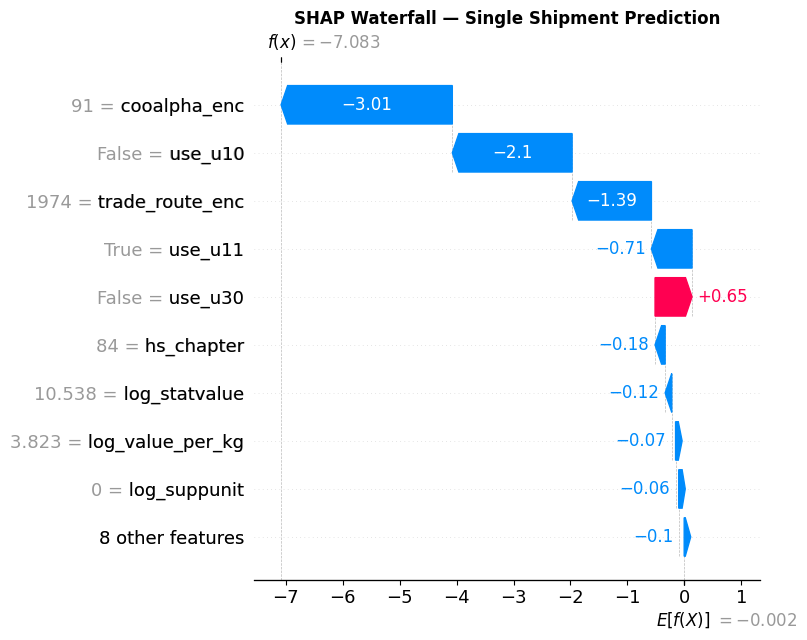

[SAVED] shap_waterfall_single.png


In [70]:

print("\n[XGB] Training XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# scale_pos_weight handles class imbalance in XGBoost
# = number of negatives / number of positives

xgb_model = xgb.XGBClassifier(
    n_estimators=300,           # number of boosting rounds
    max_depth=6,                # maximum tree depth
    learning_rate=0.1,          # shrinkage — prevents overfitting
    subsample=0.8,              # fraction of training data per tree
    colsample_bytree=0.8,       # fraction of features per tree
    min_child_weight=5,         # minimum sum of weights in a child node
    gamma=0.1,                  # minimum loss reduction for split
    reg_alpha=0.1,              # L1 regularisation (Lasso)
    reg_lambda=1.0,             # L2 regularisation (Ridge)
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("[XGB] Training complete")
res_xgb = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)
results.append(res_xgb)

# ── XGBoost built-in feature importance ──────────────────────────────────────
xgb_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#2563EB')
plt.title('XGBoost — Top 12 Feature Importances', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] xgb_feature_importance.png")

# ── SHAP Explainability ───────────────────────────────────────────────────────
print("\n[SHAP] Computing SHAP values (this may take ~30 seconds)...")
print("       SHAP = SHapley Additive exPlanations")
print("       Tells us WHY the model made each prediction")

# Use a sample of 2,000 test rows for speed (SHAP on all 44k rows is slow)
shap_sample_size = 2000
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), size=shap_sample_size, replace=False)
X_test_shap = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

# SHAP summary plot — shows which features matter most across all predictions
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_summary_bar.png")

# SHAP beeswarm plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_summary_beeswarm.png")

# SHAP waterfall for a single prediction (most interpretable for a manager)
print("\n[SHAP] Explaining a single prediction (waterfall plot):")
sample_idx = 0
print(f"       Shipment sample index: {shap_idx[sample_idx]}")
print(f"       True label : {'Eligible'     if y_test[shap_idx[sample_idx]]==1 else 'Not Eligible'}")
print(f"       Predicted  : {'Eligible'     if xgb_pred[shap_idx[sample_idx]]==1 else 'Not Eligible'}")
print(f"       Probability: {xgb_prob[shap_idx[sample_idx]]:.4f}")

explanation = shap.Explanation(
    values    = shap_values[sample_idx],
    base_values = explainer.expected_value,
    data      = X_test_shap[sample_idx],
    feature_names = feature_cols
)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall — Single Shipment Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_single.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_waterfall_single.png")

In [71]:
print("\n" + "=" * 65)
print("  MODEL 4: LSTM / RNN — DEEP LEARNING MODEL")
print("=" * 65)


  MODEL 4: LSTM / RNN — DEEP LEARNING MODEL



[LSTM] Input shape : (177563, 1, 17)
       (samples, timesteps=1, features=17)


Model: "LSTM_SCM_Delay_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)


[LSTM] Training LSTM model...
Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8371 - auc: 0.9410 - loss: 0.2110 - precision: 0.9728 - recall: 0.7671 - val_accuracy: 0.8785 - val_auc: 0.9684 - val_loss: 0.2239 - val_precision: 0.9742 - val_recall: 0.8326
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8771 - auc: 0.9659 - loss: 0.1481 - precision: 0.9670 - recall: 0.8366 - val_accuracy: 0.8833 - val_auc: 0.9694 - val_loss: 0.2188 - val_precision: 0.9686 - val_recall: 0.8455
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8794 - auc: 0.9671 - loss: 0.1462 - precision: 0.9669 - recall: 0.8404 - val_accuracy: 0.8834 - val_auc: 0.9701 - val_loss: 0.2171 - val_precision: 0.9696 - val_recall: 0.8447
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8790 - auc: 0.9676 - loss: 0.1455 - precision: 0.9675 - recall: 0.8392 - val_accuracy: 0.8825 - val_auc: 0.9708 - val_loss: 0.2162 - val_precision: 0.9726 - val_recall: 0.84

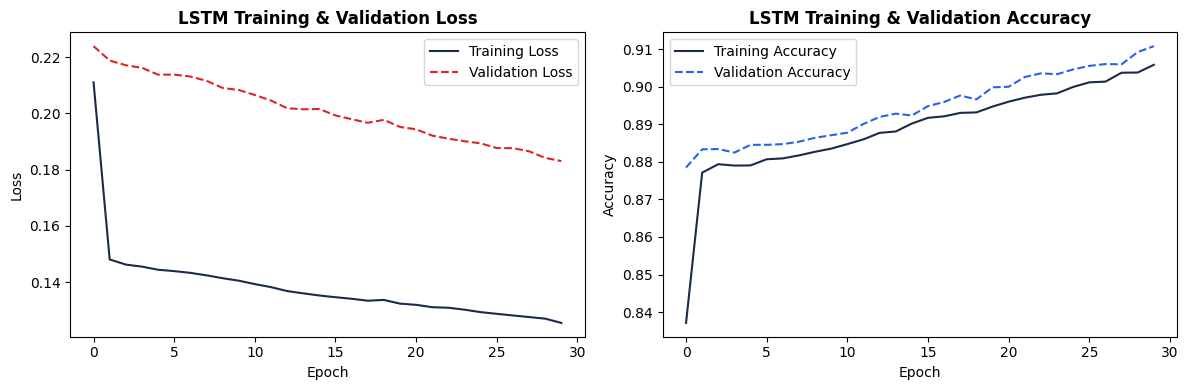

[SAVED] lstm_training_history.png

  RESULTS: LSTM / RNN
  Accuracy     : 90.70%
  F1-Score     : 0.9082
  ROC-AUC      : 0.9805
  True Positives  (TP): 25,152  — correctly predicted eligible
  True Negatives  (TN): 15,111  — correctly predicted not eligible
  False Positives (FP): 850  — predicted eligible, actually not
  False Negatives (FN): 3,278  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.82      0.95      0.88     15961
    Eligible (1)       0.97      0.88      0.92     28430

        accuracy                           0.91     44391
       macro avg       0.89      0.92      0.90     44391
    weighted avg       0.91      0.91      0.91     44391



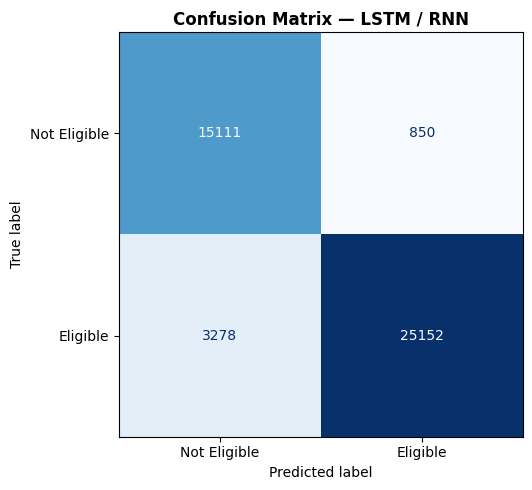

[SAVED] cm_lstm___rnn.png


In [72]:
n_features = X_train_scaled.shape[1]

# Reshape for LSTM: [samples, timesteps=1, features]
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, n_features)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  1, n_features)

print(f"\n[LSTM] Input shape : {X_train_lstm.shape}")
print(f"       (samples, timesteps=1, features={n_features})")

# Build LSTM architecture
tf.random.set_seed(42)

lstm_model = Sequential([
    # LSTM layer: 64 units, returns sequences=False (single output)
    LSTM(64,
         input_shape=(1, n_features),
         return_sequences=False,
         name='lstm_layer'),

    # Dropout: randomly drops 30% of neurons during training → prevents overfitting
    Dropout(0.3, name='dropout_1'),

    # Dense hidden layer: 32 neurons, ReLU activation
    Dense(32, activation='relu', name='dense_1'),

    # Second dropout layer
    Dropout(0.2, name='dropout_2'),

    # Output layer: 1 neuron, sigmoid → outputs probability between 0 and 1
    Dense(1, activation='sigmoid', name='output')
], name='LSTM_SCM_Delay_Model')

lstm_model.summary()

# Compile with binary cross-entropy loss (standard for binary classification)
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Early stopping: stop training if validation loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  # restore weights from best epoch
    verbose=1
)

print("\n[LSTM] Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=30,              # maximum epochs
    batch_size=512,         # larger batch = faster training
    validation_split=0.15,  # 15% of training data used for validation
    callbacks=[early_stop],
    class_weight={0: 1.0, 1: 0.5},  # mild upweighting of not-eligible class
    verbose=1
)

print(f"\n[LSTM] Training stopped at epoch {len(history.history['loss'])}")

# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss',   color='#1B2A4A')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#DC2626', linestyle='--')
axes[0].set_title('LSTM Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='#1B2A4A')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#2563EB', linestyle='--')
axes[1].set_title('LSTM Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] lstm_training_history.png")

# Evaluate LSTM
lstm_prob_raw = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_pred     = (lstm_prob_raw >= 0.5).astype(int)

res_lstm = evaluate_model("LSTM / RNN", y_test, lstm_pred, lstm_prob_raw)
results.append(res_lstm)


  FINAL COMPARISON — ALL 4 MODELS

              model  accuracy_pct  f1_rounded  auc_rounded
Logistic Regression         86.87      0.8686       0.9587
      Random Forest         99.19      0.9919       0.9992
            XGBoost         99.67      0.9967       0.9997
         LSTM / RNN         90.70      0.9082       0.9805


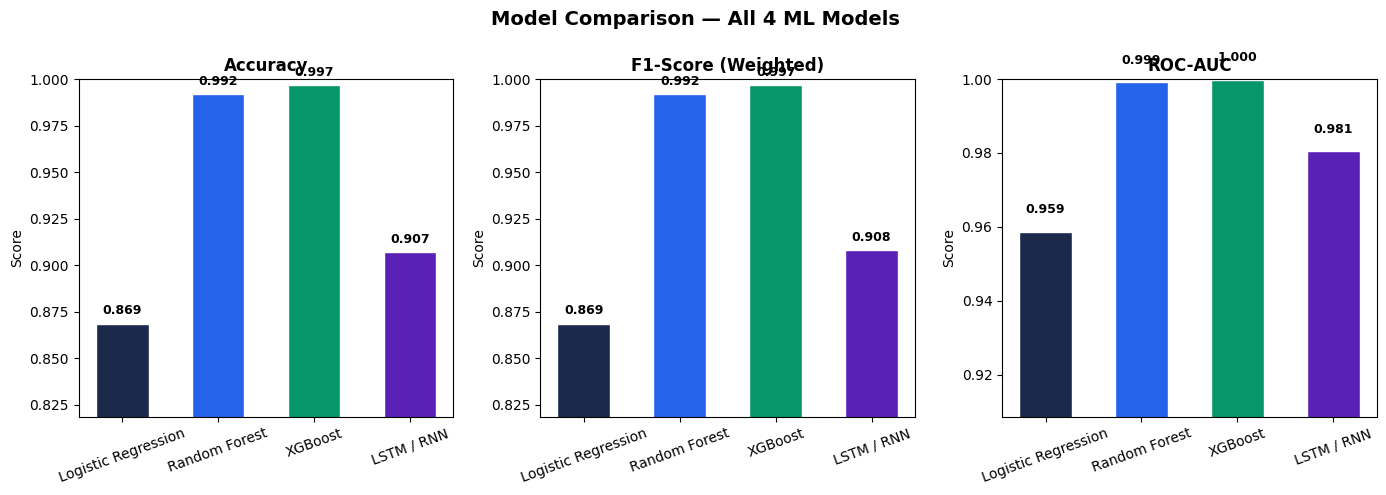

[SAVED] model_comparison_final.png

  PIPELINE COMPLETE

  Best Model   : XGBoost
  F1-Score     : 0.9967
  Accuracy     : 99.67%
  ROC-AUC      : 0.9997

  Charts saved:
    → eda_01_eligibility_distribution.png
    → eda_02_top_countries.png
    → eda_03_eligibility_by_origin.png
    → eda_04_statvalue_distribution.png
    → feat_01_log_transforms.png
    → feat_02_correlation_heatmap.png
    → cm_logistic_regression.png
    → lr_feature_coefficients.png
    → cm_random_forest.png
    → rf_feature_importance.png
    → cm_xgboost.png
    → xgb_feature_importance.png
    → shap_summary_bar.png
    → shap_summary_beeswarm.png
    → shap_waterfall_single.png
    → lstm_training_history.png
    → cm_lstm___rnn.png
    → model_comparison_final.png


In [73]:

print("\n" + "=" * 65)
print("  FINAL COMPARISON — ALL 4 MODELS")
print("=" * 65)

results_df = pd.DataFrame(results)
results_df['accuracy_pct'] = (results_df['accuracy'] * 100).round(2)
results_df['f1_rounded']   = results_df['f1'].round(4)
results_df['auc_rounded']  = results_df['auc'].round(4)

print("\n" + results_df[['model','accuracy_pct','f1_rounded','auc_rounded']].to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics    = ['accuracy', 'f1', 'auc']
titles     = ['Accuracy', 'F1-Score (Weighted)', 'ROC-AUC']
colours    = ['#1B2A4A', '#2563EB', '#059669', '#5B21B6']
bar_labels = results_df['model'].tolist()

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].tolist()
    bars = ax.bar(bar_labels, vals, color=colours, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(min(vals) - 0.05, 1.0)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — All 4 ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] model_comparison_final.png")

# Best model summary
best_model = results_df.loc[results_df['f1'].idxmax(), 'model']
best_f1    = results_df['f1'].max()
best_acc   = results_df.loc[results_df['f1'].idxmax(), 'accuracy'] * 100
best_auc   = results_df.loc[results_df['f1'].idxmax(), 'auc']

print("\n" + "=" * 65)
print("  PIPELINE COMPLETE")
print("=" * 65)
print(f"\n  Best Model   : {best_model}")
print(f"  F1-Score     : {best_f1:.4f}")
print(f"  Accuracy     : {best_acc:.2f}%")
print(f"  ROC-AUC      : {best_auc:.4f}")
print(f"\n  Charts saved:")
charts = [
    'eda_01_eligibility_distribution.png',
    'eda_02_top_countries.png',
    'eda_03_eligibility_by_origin.png',
    'eda_04_statvalue_distribution.png',
    'feat_01_log_transforms.png',
    'feat_02_correlation_heatmap.png',
    'cm_logistic_regression.png',
    'lr_feature_coefficients.png',
    'cm_random_forest.png',
    'rf_feature_importance.png',
    'cm_xgboost.png',
    'xgb_feature_importance.png',
    'shap_summary_bar.png',
    'shap_summary_beeswarm.png',
    'shap_waterfall_single.png',
    'lstm_training_history.png',
    'cm_lstm___rnn.png',
    'model_comparison_final.png',
]
for c in charts:
    print(f"    → {c}")
